# Spherical Cauchy VAE for SMILES Dataset

In [ ]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import pandas as pd

class ProgressBar:
    def __init__(self, iterable=None, **kwargs):
        self.iterable = iterable
        self.kwargs = kwargs
        self.is_notebook = False
        
        try:
            from tqdm.notebook import tqdm as notebook_tqdm
            test_bar = notebook_tqdm(range(1), leave=False)
            for _ in test_bar: pass
            self.tqdm = notebook_tqdm
            self.is_notebook = True
        except (ImportError, Exception) as e:
            print(f"Using standard tqdm progress bar (notebook version unavailable: {str(e)})")
            self.tqdm = std_tqdm
            
    def __call__(self, iterable=None, **kwargs):
        if iterable is None:
            iterable = self.iterable
        
        all_kwargs = {**self.kwargs}
        all_kwargs.update(kwargs)
        
        return self.tqdm(iterable, **all_kwargs)

tqdm = ProgressBar()

sys.path.append(os.path.abspath('..'))

from src.model import SpCauchyVAE
from src.config import SpCauchyVAEConfig
from src.utils import set_all_seeds

  0%|          | 0/1 [00:00<?, ?it/s]

## 1. Data Preparation



Shape of the DataFrame: (16087, 5)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16087 entries, 0 to 16086
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SMILES     16087 non-null  object 
 1   pIC50      15037 non-null  float64
 2   mol        16087 non-null  object 
 3   num_atoms  16087 non-null  int64  
 4   logP       16087 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 628.5+ KB

Statistics for SMILES string lengths:
count    16087.000000
mean        32.379748
std         15.490876
min          3.000000
25%         21.000000
50%         30.000000
75%         40.000000
max        167.000000
Name: smiles_length, dtype: float64


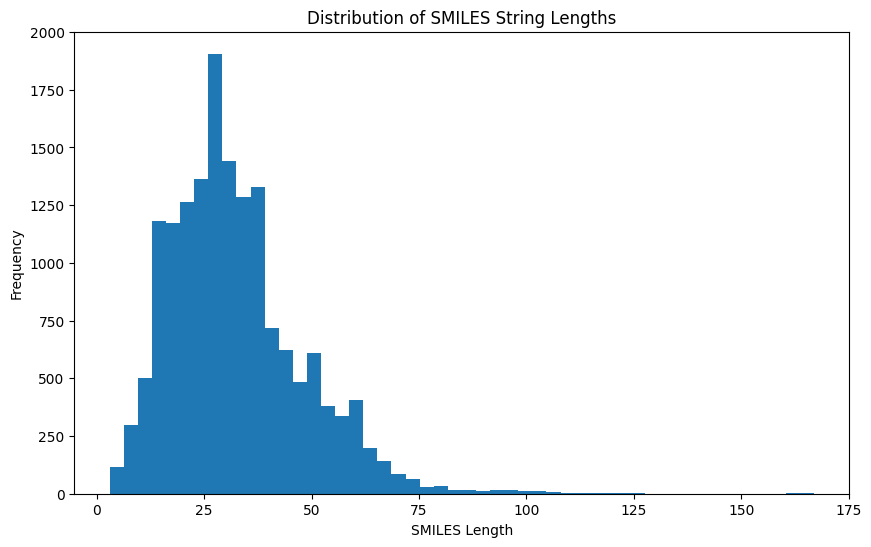

In [62]:
file_path = os.path.join('..', 'data', 'SMILES_Big_Data_Set.csv')

df_smiles = pd.read_csv(file_path)
print(f"\nShape of the DataFrame: {df_smiles.shape}")

print("\nDataFrame Info:")
df_smiles.info()


smiles_column_name = "SMILES"
df_smiles['smiles_length'] = df_smiles[smiles_column_name].astype(str).apply(len)
print("\nStatistics for SMILES string lengths:")
print(df_smiles['smiles_length'].describe())

plt.figure(figsize=(10, 6))
df_smiles['smiles_length'].hist(bins=50)
plt.title('Distribution of SMILES String Lengths')
plt.xlabel('SMILES Length')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

Original number of SMILES: 16087
Number of SMILES after filtering (length <= 73): 15873
Percentage of data retained: 98.67%

Statistics for filtered SMILES string lengths:
count    15873.000000
mean        31.621622
std         14.048253
min          3.000000
25%         21.000000
50%         30.000000
75%         40.000000
max         73.000000
Name: smiles_length, dtype: float64


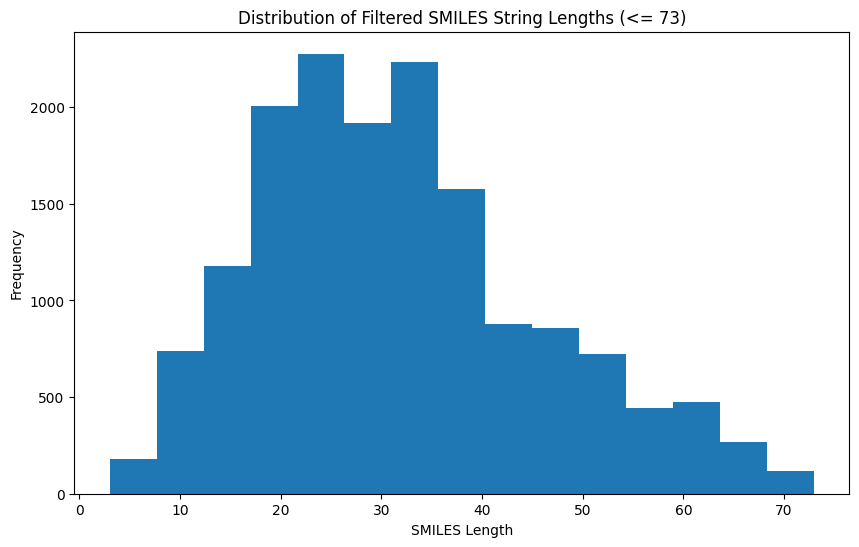

In [ ]:
# Your chosen max SMILES character length
n_smiles_chars = 73

# Filter the DataFrame
df_filtered = df_smiles[df_smiles['smiles_length'] <= n_smiles_chars].copy() # Use .copy() to avoid SettingWithCopyWarning

# See how much data we've retained
original_count = len(df_smiles)
filtered_count = len(df_filtered)
percentage_retained = (filtered_count / original_count) * 100

print(f"Original number of SMILES: {original_count}")
print(f"Number of SMILES after filtering (length <= {n_smiles_chars}): {filtered_count}")
print(f"Percentage of data retained: {percentage_retained:.2f}%")

print("\nStatistics for filtered SMILES string lengths:")
print(df_filtered['smiles_length'].describe())

plt.figure(figsize=(10, 6))
df_filtered['smiles_length'].hist(bins=15)
plt.title(f'Distribution of Filtered SMILES String Lengths (<= {n_smiles_chars})')
plt.xlabel('SMILES Length')
plt.ylabel('Frequency')
plt.grid(False)
plt.show()

smiles_series = df_filtered[smiles_column_name]

In [ ]:
PAD_TOKEN = "<pad>"  # Padding token
SOS_TOKEN = "<sos>"  # Start-of-sequence token
EOS_TOKEN = "<eos>"  # End-of-sequence token

all_chars = set()
for smiles in smiles_series:
    all_chars.update(list(smiles))

sorted_chars = sorted(list(all_chars))

# Create character-to-integer and integer-to-character mappings
# Add special tokens first to ensure they have fixed indices (e.g., 0, 1, 2)
char_to_int = {PAD_TOKEN: 0, SOS_TOKEN: 1, EOS_TOKEN: 2}
current_idx = 3 # Start actual SMILES characters from index 3
for char in sorted_chars:
    char_to_int[char] = current_idx
    current_idx += 1

int_to_char = {idx: char for char, idx in char_to_int.items()}

vocab_size = len(char_to_int)

print(f"\nVocabulary created with {vocab_size} unique characters (including special tokens).")
print(f"Character to Integer mapping (first 10): {list(char_to_int.items())[:10]}")
print(f"Integer to Character mapping (first 10): {list(int_to_char.items())[:10]}")

max_seq_len = n_smiles_chars + 2 # +2 for <sos> and <eos>
print(f"\nMax sequence length for transformer input (after adding SOS/EOS and padding): {max_seq_len}")


Vocabulary created with 36 unique characters (including special tokens).
Character to Integer mapping (first 10): [('<pad>', 0), ('<sos>', 1), ('<eos>', 2), ('#', 3), ('(', 4), (')', 5), ('+', 6), ('-', 7), ('1', 8), ('2', 9)]
Integer to Character mapping (first 10): [(0, '<pad>'), (1, '<sos>'), (2, '<eos>'), (3, '#'), (4, '('), (5, ')'), (6, '+'), (7, '-'), (8, '1'), (9, '2')]

Max sequence length for transformer input (after adding SOS/EOS and padding): 75


In [65]:
smiles_series

0               O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1cccs1
1        O=c1cc(-c2nc(-c3ccc(-c4cn(CCP(=O)(O)O)nn4)cc3)...
2                   NC(=O)c1ccc2c(c1)nc(C1CCC(O)CC1)n2CCCO
3                      NCCCn1c(C2CCNCC2)nc2cc(C(N)=O)ccc21
4                        CNC(=S)Nc1cccc(-c2cnc3ccccc3n2)c1
                               ...                        
16082                 S=C(NN=C(c1ccccn1)c1ccccn1)Nc1ccccc1
16083                              S=C=NCCCCCCCCCCc1ccccc1
16084                                S=C=NCCCCCCCCc1ccccc1
16085                S=c1[nH]nc(Cn2ccc3ccccc32)n1-c1ccccc1
16086                     N=[N+]=NC=Cc1ccc([N+](=O)[O-])o1
Name: SMILES, Length: 15873, dtype: object

In [ ]:
def preprocess_smiles(smiles_string, char_to_int_map, max_len):
    """
    Tokenizes a SMILES string, adds SOS/EOS tokens, converts to integers, and pads.
    """
    token_sequence = [char_to_int_map[SOS_TOKEN]]

    for char in smiles_string[:max_len - 2]: # -2 to leave space for SOS and EOS
        token_sequence.append(char_to_int_map.get(char, char_to_int_map[PAD_TOKEN])) # Use PAD for unknown chars, though vocab should be complete

    token_sequence.append(char_to_int_map[EOS_TOKEN])

    padding_needed = max_len - len(token_sequence)
    if padding_needed > 0:
        token_sequence.extend([char_to_int_map[PAD_TOKEN]] * padding_needed)
    
    # Ensure sequence is exactly max_len (defensive truncation, mostly for an unexpected case)
    return token_sequence[:max_len]

# Test the function with an example SMILES string
example_smiles = "CCO" # A simple SMILES
if not smiles_series.empty:
    example_smiles = smiles_series.iloc[0] 

print(f"\nExample SMILES string: {example_smiles}")
processed_example = preprocess_smiles(example_smiles, char_to_int, max_seq_len)
print(f"Processed integer sequence (length {len(processed_example)}):")
print(processed_example)

decoded_example = "".join([int_to_char.get(i, '?') for i in processed_example if i != char_to_int[PAD_TOKEN] and i != char_to_int[SOS_TOKEN] and i != char_to_int[EOS_TOKEN]])
print(f"Quick decoded check (SMILES part): {decoded_example}")
assert decoded_example == example_smiles # Check if the core SMILES part matches


Example SMILES string: O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1cccs1
Processed integer sequence (length 75):
[1, 23, 15, 25, 4, 15, 23, 5, 4, 22, 28, 8, 28, 28, 28, 28, 4, 7, 28, 9, 28, 32, 28, 10, 28, 28, 28, 28, 28, 10, 32, 9, 5, 28, 8, 5, 28, 8, 28, 28, 28, 35, 8, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Quick decoded check (SMILES part): O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1cccs1


In [ ]:
# Apply the preprocessing to all SMILES strings in the filtered series
processed_sequences = smiles_series.apply(lambda x: preprocess_smiles(x, char_to_int, max_seq_len))

df_filtered['processed_sequence'] = processed_sequences

print("\nFirst 5 processed sequences:")
print(df_filtered[['SMILES', 'processed_sequence']].head())

list_of_sequences = list(processed_sequences) 
sequences_tensor = torch.tensor(list_of_sequences, dtype=torch.long)

print(f"\nShape of the PyTorch tensor: {sequences_tensor.shape}")
print(f"Data type of the PyTorch tensor: {sequences_tensor.dtype}")

print("\nFirst 3 sequences from the tensor:")
print(sequences_tensor[:3])


First 5 processed sequences:
                                              SMILES  \
0         O=S(=O)(Nc1cccc(-c2cnc3ccccc3n2)c1)c1cccs1   
1  O=c1cc(-c2nc(-c3ccc(-c4cn(CCP(=O)(O)O)nn4)cc3)...   
2             NC(=O)c1ccc2c(c1)nc(C1CCC(O)CC1)n2CCCO   
3                NCCCn1c(C2CCNCC2)nc2cc(C(N)=O)ccc21   
4                  CNC(=S)Nc1cccc(-c2cnc3ccccc3n2)c1   

                                  processed_sequence  
0  [1, 23, 15, 25, 4, 15, 23, 5, 4, 22, 28, 8, 28...  
1  [1, 23, 15, 28, 8, 28, 28, 4, 7, 28, 9, 32, 28...  
2  [1, 22, 18, 4, 15, 23, 5, 28, 8, 28, 28, 28, 9...  
3  [1, 22, 18, 18, 18, 32, 8, 28, 4, 18, 9, 18, 1...  
4  [1, 18, 22, 18, 4, 15, 25, 5, 22, 28, 8, 28, 2...  

Shape of the PyTorch tensor: torch.Size([15873, 75])
Data type of the PyTorch tensor: torch.int64

First 3 sequences from the tensor:
tensor([[ 1, 23, 15, 25,  4, 15, 23,  5,  4, 22, 28,  8, 28, 28, 28, 28,  4,  7,
         28,  9, 28, 32, 28, 10, 28, 28, 28, 28, 28, 10, 32,  9,  5, 28,  8,  5,
      

## 2. Model Configuration

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split


train_ratio = 0.8
num_samples = sequences_tensor.shape[0]
train_size = int(train_ratio * num_samples)
val_size = num_samples - train_size

print(f"Total samples: {num_samples}")
print(f"Training samples: {train_size}")
print(f"Validation samples: {val_size}")

dataset = TensorDataset(sequences_tensor) # Each item is a single sequence

torch.manual_seed(42)  
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])


print(f"\nLength of train_dataset: {len(train_dataset)}")
print(f"Length of val_dataset: {len(val_dataset)}")

Total samples: 15873
Training samples: 12698
Validation samples: 3175

Length of train_dataset: 12698
Length of val_dataset: 3175


In [ ]:
smiles_vae_config = SpCauchyVAEConfig(
    input_dim= max_seq_len, # Or some other placeholder, as transformer uses max_seq_len
    
    # Latent space
    latent_dim=128,             
    distribution_type="spcauchy", 
    
    encoder_type="transformer",
    decoder_type="transformer",
    hidden_dims=[256, 128],    
                               
    
    # General VAE params
    activation="relu",          
    dropout_rate=0.1,           
    kl_weight=0.2,              
    
    # Transformer specific
    num_heads=4,                
    num_layers=4,             

    vocab_size=vocab_size,
    embedding_dim=256,         
    max_seq_len=max_seq_len,
    pad_token_id=char_to_int[PAD_TOKEN],
 
)
smiles_vae_config.device = "cuda"

if isinstance(smiles_vae_config.input_dim, int): 
    smiles_vae_config.is_image_input = False

print("\nSMILES VAE Configuration:")

import json
def print_config(config):
    config_dict = {slot: getattr(config, slot) for slot in config.__dataclass_fields__}
    config_dict['is_image_input'] = config.is_image_input 
    print(json.dumps(config_dict, indent=2))

print_config(smiles_vae_config)
print(f"Configured device: {smiles_vae_config.device}")


SMILES VAE Configuration:
{
  "input_dim": 75,
  "latent_dim": 128,
  "hidden_dims": [
    256,
    128
  ],
  "distribution_type": "spcauchy",
  "encoder_type": "transformer",
  "decoder_type": "transformer",
  "channels": null,
  "kernel_sizes": null,
  "strides": null,
  "num_heads": 4,
  "num_layers": 4,
  "dropout": 0.1,
  "vocab_size": 36,
  "embedding_dim": 256,
  "max_seq_len": 75,
  "pad_token_id": 0,
  "learning_rate": 0.001,
  "beta": 1.0,
  "batch_size": 128,
  "optimizer": "adam",
  "scheduler": "cosine",
  "weight_decay": 0.0,
  "device": "cuda",
  "seed": 42,
  "is_image_input": false
}
Configured device: cuda


In [ ]:
batch_size = 256 

train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,  
    num_workers=1, 
    pin_memory=True if smiles_vae_config.device == "cuda" else False 
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False, 
    num_workers=1, 
    pin_memory=True if smiles_vae_config.device == "cuda" else False 
)

print(f"\nCreated DataLoaders with batch_size: {batch_size}")
print(f"Number of batches in train_dataloader: {len(train_dataloader)}")
print(f"Number of batches in val_dataloader: {len(val_dataloader)}")


try:
    first_batch_train = next(iter(train_dataloader))
    sequences_in_batch = first_batch_train[0] 
    print(f"\nShape of a training batch (sequences): {sequences_in_batch.shape}")
    print(f"Data type of sequences in batch: {sequences_in_batch.dtype}")
except Exception as e:
    print(f"Could not retrieve a batch from train_dataloader: {e}")


Created DataLoaders with batch_size: 256
Number of batches in train_dataloader: 50
Number of batches in val_dataloader: 13

Shape of a training batch (sequences): torch.Size([256, 75])
Data type of sequences in batch: torch.int64


In [71]:
device = smiles_vae_config.device
model = SpCauchyVAE(smiles_vae_config).to(device)
print(f"Model moved to device: {device}")
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters in the model: {num_params:,}")

Model moved to device: cuda
Number of trainable parameters in the model: 12,342,437


## Model Fit

In [ ]:
def train_vae(model, train_loader, optimizer, epoch, device, config, current_kl_weight):
    model.train()  
    train_loss_total = 0
    recon_loss_total = 0
    kl_loss_total = 0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch} [Train]", leave=False)
    
    original_model_kl_weight = model.config.kl_weight
    model.config.kl_weight = current_kl_weight
    for batch_idx, batch_data in enumerate(progress_bar):
        if isinstance(batch_data, list) or isinstance(batch_data, tuple):
            sequences = batch_data[0].to(device)
        else: # Should not happen with TensorDataset but as a fallback
            sequences = batch_data.to(device) 
        
        optimizer.zero_grad()
        
        recon_batch, mu, second_param = model(sequences)
        loss, recon_loss, kl_loss = model.loss_function(sequences, recon_batch, mu, second_param)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Try max_norm=1.0 or 5.0
        optimizer.step()
        
        # Track losses
        train_loss_total += loss.item()
        recon_loss_total += recon_loss.item()
        kl_loss_total += kl_loss.item()
        
        # Update progress bar
        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}", 
            recon=f"{recon_loss.item():.4f}", 
            kl=f"{kl_loss.item():.4f}"
        )
    
    model.config.kl_weight = original_model_kl_weight
    avg_loss = train_loss_total / len(train_loader)
    avg_recon = recon_loss_total / len(train_loader)
    avg_kl = kl_loss_total / len(train_loader)
    
    print(f"====> Epoch: {epoch} [Train] Avg loss: {avg_loss:.4f}, Avg Recon: {avg_recon:.4f}, Avg KL: {avg_kl:.4f}")
    
    return avg_loss, avg_recon, avg_kl

def validate_vae(model, val_loader, epoch, device, config, current_kl_weight): 
    model.eval()  
    val_loss_total = 0
    recon_loss_total = 0
    kl_loss_total = 0
    
    progress_bar = tqdm(val_loader, desc=f"Epoch {epoch} [Val]", leave=False)
    original_model_kl_weight = model.config.kl_weight
    model.config.kl_weight = current_kl_weight
    with torch.no_grad(): 
        for batch_idx, batch_data in enumerate(progress_bar):
            if isinstance(batch_data, list) or isinstance(batch_data, tuple):
                sequences = batch_data[0].to(device)
            else:
                sequences = batch_data.to(device)
            

            recon_batch, mu, second_param = model(sequences)
            loss, recon_loss, kl_loss = model.loss_function(sequences, recon_batch, mu, second_param)
            val_loss_total += loss.item()
            recon_loss_total += recon_loss.item()
            kl_loss_total += kl_loss.item()

            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}", 
                recon=f"{recon_loss.item():.4f}", 
                kl=f"{kl_loss.item():.4f}"
            )

    model.config.kl_weight = original_model_kl_weight
    # Calculate average losses for the validation set
    avg_loss = val_loss_total / len(val_loader)
    avg_recon = recon_loss_total / len(val_loader)
    avg_kl = kl_loss_total / len(val_loader)
    
    print(f"====> Epoch: {epoch} [Val] Avg loss: {avg_loss:.4f}, Avg Recon: {avg_recon:.4f}, Avg KL: {avg_kl:.4f}")
    
    return avg_loss, avg_recon, avg_kl

def set_all_seeds(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed) 
        # torch.backends.cudnn.deterministic = True
        # torch.backends.cudnn.benchmark = False

In [ ]:
learning_rate = 0.0001
optimizer_name = getattr(smiles_vae_config, 'optimizer', 'adamw').lower()
weight_decay = 0.01 

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
print(f"Using optimizer: {type(optimizer).__name__} with LR: {learning_rate}, Weight Decay: {weight_decay}")


scheduler_config_name = getattr(smiles_vae_config, 'scheduler', 'ReduceLROnPlateau').lower()
scheduler = None 

if scheduler_config_name == 'reducelronplateau':
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min',    # Reduce LR when the monitored quantity has stopped decreasing
        factor=0.5,    # Factor by which the learning rate will be reduced. new_lr = lr * factor
        patience=5,    # Number of epochs with no improvement after which learning rate will be reduced.
        verbose=True   
    )
    print("Using ReduceLROnPlateau scheduler.")



num_epochs = 500 
seed_value = getattr(smiles_vae_config, 'seed', 42)
initial_zero_kl_epochs = 10
ramp_up_duration_epochs = 15
target_kl_weight = 0.2


set_all_seeds(seed_value)
print(f"Set all seeds to: {seed_value}")

history = {
    'train_loss': [], 'train_recon_loss': [], 'train_kl_loss': [],
    'val_loss': [], 'val_recon_loss': [], 'val_kl_loss': []
}

print(f"\nStarting training for {num_epochs} epochs on device: {device}...")

for epoch in range(1, num_epochs + 1):

    if epoch <= initial_zero_kl_epochs:
        current_kl_weight = 0.0
    elif ramp_up_duration_epochs <= 0: #
        current_kl_weight = target_kl_weight
    elif epoch <= initial_zero_kl_epochs + ramp_up_duration_epochs:
        current_ramp_epoch = epoch - initial_zero_kl_epochs
        current_kl_weight = target_kl_weight * (current_ramp_epoch / ramp_up_duration_epochs)
    else:
        current_kl_weight = target_kl_weight
    avg_train_loss, avg_train_recon, avg_train_kl = train_vae(
        model, 
        train_dataloader, 
        optimizer, 
        epoch, 
        device, 
        smiles_vae_config, # Pass config
        current_kl_weight
    )
    history['train_loss'].append(avg_train_loss)
    history['train_recon_loss'].append(avg_train_recon)
    history['train_kl_loss'].append(avg_train_kl)
    
    avg_val_loss, avg_val_recon, avg_val_kl = validate_vae(
        model, 
        val_dataloader, # Use val_dataloader here
        epoch,
        device,
        smiles_vae_config, # Pass config
        current_kl_weight
    )
    history['val_loss'].append(avg_val_loss)
    history['val_recon_loss'].append(avg_val_recon)
    history['val_kl_loss'].append(avg_val_kl)

    if scheduler:
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(avg_val_loss) 

    current_lr = optimizer.param_groups[0]['lr']
    print("-" * 50)

print("Training finished.")


Using optimizer: AdamW with LR: 0.0001, Weight Decay: 0.01
Set all seeds to: 42

Starting training for 500 epochs on device: cuda...


Epoch 1 [Train]:   0%|          | 0/50 [00:00<?, ?it/s]

====> Epoch: 1 [Train] Avg loss: 84.2866, Avg Recon: 84.2866, Avg KL: 464.9328


Epoch 1 [Val]:   0%|          | 0/13 [00:00<?, ?it/s]

====> Epoch: 1 [Val] Avg loss: 77.0204, Avg Recon: 77.0204, Avg KL: 346.8553
--------------------------------------------------


...

====> Epoch: 499 [Val] Avg loss: 41.9422, Avg Recon: 2.0350, Avg KL: 199.5360
--------------------------------------------------


Epoch 500 [Train]:   0%|          | 0/50 [00:00<?, ?it/s]

====> Epoch: 500 [Train] Avg loss: 16.9729, Avg Recon: 3.7721, Avg KL: 66.0040


Epoch 500 [Val]:   0%|          | 0/13 [00:00<?, ?it/s]

====> Epoch: 500 [Val] Avg loss: 41.8547, Avg Recon: 2.0227, Avg KL: 199.1604
--------------------------------------------------
Training finished.


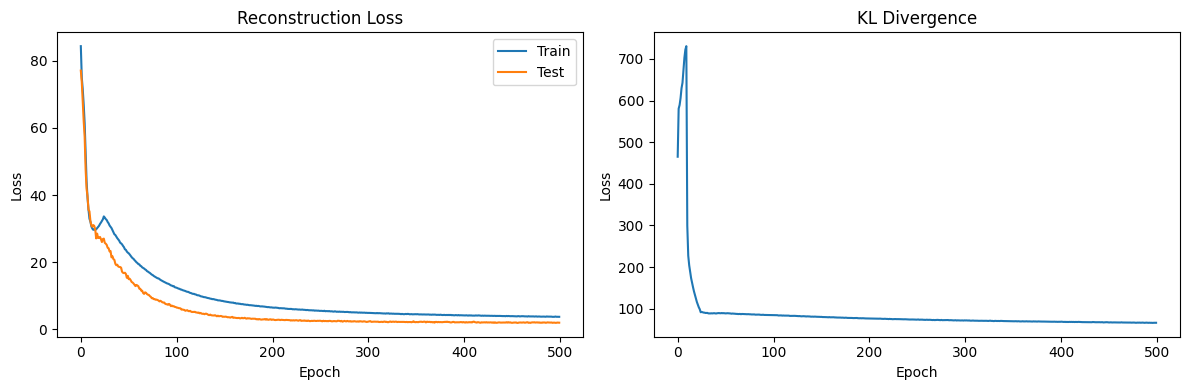

In [74]:
plt.figure(figsize=(12, 4))

# Plot total loss
#plt.subplot(1, 3, 1)
#plt.plot(history["train_loss"], label='Train')
#plt.plot(history["val_loss"], label='Test')
#plt.xlabel('Epoch')
#plt.ylabel('Loss')
#plt.title('Total Loss')
#plt.legend()

# Plot reconstruction loss
plt.subplot(1, 2, 1)
plt.plot(history["train_recon_loss"], label='Train')
plt.plot(history["val_recon_loss"], label='Test')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Reconstruction Loss')
plt.legend()

# Plot KL divergence
plt.subplot(1, 2, 2)
plt.plot(history["train_kl_loss"], label='Train')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('KL Divergence')

plt.tight_layout()
plt.show()

In [75]:
# save history
history_df = pd.DataFrame(history)
history_df.to_csv('history_spc.csv', index=False)

In [76]:
# Save the model
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': smiles_vae_config,
}, '../models/smiles_vae_spcauchy.pt')

print("Model saved to: ../models/smiles_vae_spcauchy.pt")

Model saved to: ../models/smiles_vae_spcauchy.pt


## Inference

In [ ]:
# Load the model (for testing purposes)
device = "cuda" if torch.cuda.is_available() else "cpu"
learning_rate = 0.0001
weight_decay = 0.01

checkpoint = torch.load('../models/smiles_vae_spcauchy.pt', map_location=device)
model = SpCauchyVAE(checkpoint['config']).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

In [ ]:
def token_ids_to_smiles(token_ids_tensor, int_to_char_map, sos_token_str, eos_token_str, pad_token_str):
    """
    Converts a tensor of token IDs back to a SMILES string.
    """
    if token_ids_tensor.dim() == 2 and token_ids_tensor.shape[0] == 1: # (1, max_seq_len)
        token_ids_tensor = token_ids_tensor.squeeze(0) # Shape: (max_seq_len)
    elif token_ids_tensor.dim() != 1:
        raise ValueError(f"token_ids_tensor must be 1D or 2D with batch size 1, got shape {token_ids_tensor.shape}")
        
    chars = []
    for token_id in token_ids_tensor.tolist():
        char = int_to_char_map.get(token_id)
        if char is None: 
            continue
        if char == eos_token_str:
            break 
        if char not in [sos_token_str, pad_token_str]:
            chars.append(char)
    return "".join(chars)

val_smiles_list = []
if 'val_dataset' in locals() and val_dataset is not None:
    for item_tuple in val_dataset:
        sequence_tensor = item_tuple[0].cpu() 
        val_smiles_list.append(token_ids_to_smiles(sequence_tensor, int_to_char, SOS_TOKEN, EOS_TOKEN, PAD_TOKEN))

train_smiles_list = []
if 'train_dataset' in locals() and train_dataset is not None:
    for item_tuple in train_dataset:
        sequence_tensor = item_tuple[0].cpu() 
        train_smiles_list.append(token_ids_to_smiles(sequence_tensor, int_to_char, SOS_TOKEN, EOS_TOKEN, PAD_TOKEN))

In [ ]:
from rdkit import Chem 
from rdkit import RDLogger 

def slerp(v0: torch.Tensor, v1: torch.Tensor, t: float, DOT_THRESHOLD=0.9995):
    """
    Spherical Linear Interpolation (SLERP) between two unit vectors.

    Args:
        v0 (torch.Tensor): Start unit vector. Shape (latent_dim,) or (1, latent_dim).
        v1 (torch.Tensor): End unit vector. Shape (latent_dim,) or (1, latent_dim).
        t (float): Interpolation parameter between 0 and 1.
        DOT_THRESHOLD (float): Threshold for handling nearly parallel vectors.

    Returns:
        torch.Tensor: Interpolated unit vector.
    """
    if not isinstance(v0, torch.Tensor): v0 = torch.tensor(v0, dtype=torch.float32)
    if not isinstance(v1, torch.Tensor): v1 = torch.tensor(v1, dtype=torch.float32)
    
    v0 = v0.squeeze()
    v1 = v1.squeeze()

    # Ensure inputs are unit vectors (optional, but good practice)
    # v0 = F.normalize(v0, p=2, dim=-1)
    # v1 = F.normalize(v1, p=2, dim=-1)

    dot = torch.sum(v0 * v1)

    if torch.abs(dot) > DOT_THRESHOLD:
        res = (1 - t) * v0 + t * v1
        return F.normalize(res, p=2, dim=-1)

    theta_0 = torch.acos(dot)  # angle between input vectors
    sin_theta_0 = torch.sin(theta_0)  # sine of angle
    theta_t = theta_0 * t  # angle between v0 and result
    sin_theta_t = torch.sin(theta_t)  # sine of angle between v0 and result
    sin_theta_0_minus_t = torch.sin(theta_0 - theta_t)  # sine of angle between v1 and result

    # Compute interpolated vector
    # Formula: (sin((1-t)*omega)/sin(omega)) * v0 + (sin(t*omega)/sin(omega)) * v1
    res = (sin_theta_0_minus_t / sin_theta_0) * v0 + (sin_theta_t / sin_theta_0) * v1
    return res


def logits_to_smiles(logits_sequence, int_to_char_map, sos_token_str, eos_token_str, pad_token_str):
    """
    Converts a sequence of logits to a SMILES string.
    Args:
        logits_sequence (torch.Tensor): Tensor of shape (1, max_seq_len, vocab_size) or (max_seq_len, vocab_size)
        int_to_char_map (dict): Mapping from integer token ID to character.
        sos_token_str (str): The actual start-of-sequence string (e.g., "<sos>").
        eos_token_str (str): The actual end-of-sequence string (e.g., "<eos>").
        pad_token_str (str): The actual pad token string (e.g., "<pad>").
    Returns:
        str: Decoded SMILES string.
    """
    if logits_sequence.dim() == 3 and logits_sequence.shape[0] == 1:
        logits_sequence = logits_sequence.squeeze(0) # Shape: (max_seq_len, vocab_size)
    
    predicted_indices = torch.argmax(logits_sequence, dim=-1) # Shape: (max_seq_len)
    
    chars = []
    for token_id in predicted_indices.tolist():
        char = int_to_char_map.get(token_id)
        if char == eos_token_str:
            break # Stop at EOS
        if char not in [sos_token_str, pad_token_str]: # Don't include SOS or PAD
            chars.append(char)
    return "".join(chars)


def is_smiles_valid(smiles_string: str, suppress_rdkit_errors: bool = True) -> bool:
    """
    Checks if a given SMILES string represents a chemically valid molecule using RDKit.
    (Assumes this function is defined as previously discussed)
    """
    if suppress_rdkit_errors:
        RDLogger.DisableLog('rdApp.*')
    mol = Chem.MolFromSmiles(smiles_string)
    if suppress_rdkit_errors:
        RDLogger.EnableLog('rdApp.*')
    return mol is not None

In [ ]:
import random

def run_spherical_interpolation_experiment(
    model_to_test, 
    source_smiles_list, 
    char_to_int_map, 
    int_to_char_map, 
    max_seq_len_model, 
    device_to_use, 
    sos_token_str, 
    eos_token_str, 
    pad_token_str,
    num_pairs=30, 
    num_steps=11, 
    max_cosine_similarity=0.5, 
    max_tries_per_pair=100 
):
    """
    Runs latent space interpolation experiment for a Spherical VAE.

    Args:
        model_to_test (nn.Module): The trained Spherical VAE model.
        source_smiles_list (list): A list of SMILES strings to sample pairs from.
        char_to_int_map (dict): Character to integer token mapping.
        int_to_char_map (dict): Integer token to character mapping.
        max_seq_len_model (int): Max sequence length for preprocessing.
        device_to_use (torch.device): Device to run on.
        sos_token_str (str): Start of sequence token string.
        eos_token_str (str): End of sequence token string.
        pad_token_str (str): Pad token string.
        num_pairs (int): Number of random SMILES pairs to interpolate.
        num_steps (int): Number of interpolation steps (includes endpoints).
        max_cosine_similarity (float): Maximum cosine similarity allowed between mu_enc vectors of a pair.
                                      Set to 1.0 to disable this constraint.
        max_tries_per_pair (int): Max attempts to find a suitable pair satisfying the constraint.

    Returns:
        tuple: (mean_valid_percentage, std_dev_valid_percentage)
    """
    model_to_test.eval() 
    
    path_valid_percentages = []
    pairs_found = 0

    for pair_idx in range(num_pairs):
        found_suitable_pair = False
        for _try_idx in range(max_tries_per_pair):
            if len(source_smiles_list) < 2:
                print("Warning: Not enough SMILES in source list to form a pair.")
                return np.nan, np.nan 
                
            smiles1_str, smiles2_str = random.sample(source_smiles_list, 2)
            
            tokens1_list = preprocess_smiles(smiles1_str, char_to_int_map, max_seq_len_model)
            tokens2_list = preprocess_smiles(smiles2_str, char_to_int_map, max_seq_len_model)
            
            tokens1 = torch.tensor(tokens1_list, dtype=torch.long).unsqueeze(0).to(device_to_use)
            tokens2 = torch.tensor(tokens2_list, dtype=torch.long).unsqueeze(0).to(device_to_use)

            with torch.no_grad():
                mu1_enc, _ = model_to_test.encode(tokens1) 
                mu2_enc, _ = model_to_test.encode(tokens2)
            
            mu1_enc_sq = mu1_enc.squeeze()
            mu2_enc_sq = mu2_enc.squeeze()
            
            cosine_sim = torch.dot(mu1_enc_sq, mu2_enc_sq).item() 

            if cosine_sim <= max_cosine_similarity:
                found_suitable_pair = True
                break 
        
        if not found_suitable_pair:
            print(f"Warning: Could not find a suitable pair satisfying cosine_sim <= {max_cosine_similarity:.2f} for pair {pair_idx + 1} after {max_tries_per_pair} tries. Skipping this pair.")
            continue 

        pairs_found += 1
        #print(f"\nProcessing pair {pairs_found} ({pair_idx + 1} attempts): Cosine Sim = {cosine_sim:.3f}")
        #print(f"  SMILES A: {smiles1_str}")
        #print(f"  SMILES B: {smiles2_str}")

        valid_count = 0

        with torch.no_grad():
            for i_step, t in enumerate(np.linspace(0, 1, num_steps)):
                mu_interp = slerp(mu1_enc_sq, mu2_enc_sq, t).unsqueeze(0).to(device_to_use)
                
                logits = model_to_test.decode(mu_interp)
                decoded_smiles = logits_to_smiles(logits, int_to_char_map, sos_token_str, eos_token_str, pad_token_str)
                is_valid = is_smiles_valid(decoded_smiles)
                if is_valid:
                    valid_count += 1
                
        
        if num_steps > 0:
            path_valid_percentages.append((valid_count / num_steps) * 100)
        else:
            path_valid_percentages.append(0.0) 

    if not path_valid_percentages: # If no suitable pairs were found
        print("No suitable pairs found to interpolate based on the criteria.")
        return np.nan, np.nan

    mean_valid_percentage = np.mean(path_valid_percentages)
    std_dev_valid_percentage = np.std(path_valid_percentages)
    
    return mean_valid_percentage, std_dev_valid_percentage


def calculate_exact_reconstruction_accuracy(
    model_to_evaluate,
    dataloader,
    device,
    int_to_char_map,
    sos_token_str,
    eos_token_str,
    pad_token_str,
    model_name="Model" # For print statements
):
    """
    Calculates the percentage of exact SMILES string reconstructions.
    Decodes using the mean of the latent distribution.
    """
    model_to_evaluate.eval() # Set model to evaluation mode
    total_samples = 0
    exact_matches = 0

    print(f"Calculating exact reconstruction accuracy for: {model_name}")
    with torch.no_grad(): 
        for batch_data in tqdm(dataloader, desc=f"Testing {model_name}"):
            if isinstance(batch_data, (list, tuple)):
                original_token_ids_batch = batch_data[0].to(device)
            else: 
                original_token_ids_batch = batch_data.to(device)

            latent_params = model_to_evaluate.encode(original_token_ids_batch)
            mu_latent_batch = latent_params[0] 

            output_logits_batch = model_to_evaluate.decode(mu_latent_batch)

            for i in range(original_token_ids_batch.size(0)):
                original_smiles = token_ids_to_smiles(
                    original_token_ids_batch[i].cpu(), 
                    int_to_char_map,
                    sos_token_str,
                    eos_token_str,
                    pad_token_str
                )
                
                reconstructed_smiles = logits_to_smiles(
                    output_logits_batch[i].cpu(),
                    int_to_char_map,
                    sos_token_str,
                    eos_token_str,
                    pad_token_str
                )

                if original_smiles == reconstructed_smiles:
                    exact_matches += 1
            
            total_samples += original_token_ids_batch.size(0)

    accuracy = (exact_matches / total_samples) * 100 if total_samples > 0 else 0.0
    print(f"{model_name} - Exact Matches: {exact_matches}/{total_samples} ({accuracy:.2f}%)")
    return accuracy, exact_matches, total_samples

In [ ]:
all_filtered_smiles_list = list(smiles_series)

num_pairs_experiment = 30 # Number of pairs for each run
interpolation_steps = 11
cosine_similarity_threshold = 0.5 

random.seed(42)
print(f"\n--- Running Interpolation for SpCauchy VAE (Full Dataset) ---")
mean_full, std_full = run_spherical_interpolation_experiment(
    model, all_filtered_smiles_list, char_to_int, int_to_char, max_seq_len, device,
    SOS_TOKEN, EOS_TOKEN, PAD_TOKEN,
    num_pairs=num_pairs_experiment, num_steps=interpolation_steps, 
    max_cosine_similarity=cosine_similarity_threshold
)
print(f"Full Dataset Results: Valid intermediates mean = {mean_full:.2f}% ± {std_full:.2f}%")

print(f"\n--- Running Interpolation for SpCauchy VAE (Train Dataset) ---")
mean_train, std_train = run_spherical_interpolation_experiment(
    model, train_smiles_list, char_to_int, int_to_char, max_seq_len, device,
    SOS_TOKEN, EOS_TOKEN, PAD_TOKEN,
    num_pairs=num_pairs_experiment, num_steps=interpolation_steps, 
    max_cosine_similarity=cosine_similarity_threshold
)
print(f"Train Dataset Results: Valid intermediates mean = {mean_train:.2f}% ± {std_train:.2f}%")

print(f"\n--- Running Interpolation for SpCauchy VAE (Validation Dataset) ---")
mean_val, std_val = run_spherical_interpolation_experiment(
    model, val_smiles_list, char_to_int, int_to_char, max_seq_len, device,
    SOS_TOKEN, EOS_TOKEN, PAD_TOKEN,
    num_pairs=num_pairs_experiment, num_steps=interpolation_steps, 
    max_cosine_similarity=cosine_similarity_threshold
)
print(f"Validation Dataset Results: Valid intermediates mean = {mean_val:.2f}% ± {std_val:.2f}%")


--- Running Interpolation for SpCauchy VAE (Full Dataset) ---
Full Dataset Results: Valid intermediates mean = 66.67% ± 18.83%

--- Running Interpolation for SpCauchy VAE (Train Dataset) ---
Train Dataset Results: Valid intermediates mean = 72.73% ± 12.64%

--- Running Interpolation for SpCauchy VAE (Validation Dataset) ---
Validation Dataset Results: Valid intermediates mean = 68.48% ± 18.14%


In [ ]:
cosine_similarity_threshold = 0.2 

random.seed(42)
print(f"\n--- Running Interpolation for SpCauchy VAE (Full Dataset) ---")
mean_full, std_full = run_spherical_interpolation_experiment(
    model, all_filtered_smiles_list, char_to_int, int_to_char, max_seq_len, device,
    SOS_TOKEN, EOS_TOKEN, PAD_TOKEN,
    num_pairs=num_pairs_experiment, num_steps=interpolation_steps, 
    max_cosine_similarity=cosine_similarity_threshold
)
print(f"Full Dataset Results: Valid intermediates mean = {mean_full:.2f}% ± {std_full:.2f}%")

print(f"\n--- Running Interpolation for SpCauchy VAE (Train Dataset) ---")
mean_train, std_train = run_spherical_interpolation_experiment(
    model, train_smiles_list, char_to_int, int_to_char, max_seq_len, device,
    SOS_TOKEN, EOS_TOKEN, PAD_TOKEN,
    num_pairs=num_pairs_experiment, num_steps=interpolation_steps, 
    max_cosine_similarity=cosine_similarity_threshold
)
print(f"Train Dataset Results: Valid intermediates mean = {mean_train:.2f}% ± {std_train:.2f}%")

print(f"\n--- Running Interpolation for SpCauchy VAE (Validation Dataset) ---")
mean_val, std_val = run_spherical_interpolation_experiment(
    model, val_smiles_list, char_to_int, int_to_char, max_seq_len, device,
    SOS_TOKEN, EOS_TOKEN, PAD_TOKEN,
    num_pairs=num_pairs_experiment, num_steps=interpolation_steps, 
    max_cosine_similarity=cosine_similarity_threshold
)
print(f"Validation Dataset Results: Valid intermediates mean = {mean_val:.2f}% ± {std_val:.2f}%")


--- Running Interpolation for SpCauchy VAE (Full Dataset) ---
Full Dataset Results: Valid intermediates mean = 65.45% ± 19.27%

--- Running Interpolation for SpCauchy VAE (Train Dataset) ---
Train Dataset Results: Valid intermediates mean = 70.00% ± 9.43%

--- Running Interpolation for SpCauchy VAE (Validation Dataset) ---
Validation Dataset Results: Valid intermediates mean = 66.97% ± 22.45%


In [ ]:
cosine_similarity_threshold = 0 

random.seed(42)
print(f"\n--- Running Interpolation for SpCauchy VAE (Full Dataset) ---")
mean_full, std_full = run_spherical_interpolation_experiment(
    model, all_filtered_smiles_list, char_to_int, int_to_char, max_seq_len, device,
    SOS_TOKEN, EOS_TOKEN, PAD_TOKEN,
    num_pairs=num_pairs_experiment, num_steps=interpolation_steps, 
    max_cosine_similarity=cosine_similarity_threshold
)
print(f"Full Dataset Results: Valid intermediates mean = {mean_full:.2f}% ± {std_full:.2f}%")

print(f"\n--- Running Interpolation for SpCauchy VAE (Train Dataset) ---")
mean_train, std_train = run_spherical_interpolation_experiment(
    model, train_smiles_list, char_to_int, int_to_char, max_seq_len, device,
    SOS_TOKEN, EOS_TOKEN, PAD_TOKEN,
    num_pairs=num_pairs_experiment, num_steps=interpolation_steps, 
    max_cosine_similarity=cosine_similarity_threshold
)
print(f"Train Dataset Results: Valid intermediates mean = {mean_train:.2f}% ± {std_train:.2f}%")

print(f"\n--- Running Interpolation for SpCauchy VAE (Validation Dataset) ---")
mean_val, std_val = run_spherical_interpolation_experiment(
    model, val_smiles_list, char_to_int, int_to_char, max_seq_len, device,
    SOS_TOKEN, EOS_TOKEN, PAD_TOKEN,
    num_pairs=num_pairs_experiment, num_steps=interpolation_steps, 
    max_cosine_similarity=cosine_similarity_threshold
)
print(f"Validation Dataset Results: Valid intermediates mean = {mean_val:.2f}% ± {std_val:.2f}%")


--- Running Interpolation for SpCauchy VAE (Full Dataset) ---
Full Dataset Results: Valid intermediates mean = 63.64% ± 15.75%

--- Running Interpolation for SpCauchy VAE (Train Dataset) ---
Train Dataset Results: Valid intermediates mean = 64.55% ± 12.50%

--- Running Interpolation for SpCauchy VAE (Validation Dataset) ---
Validation Dataset Results: Valid intermediates mean = 59.39% ± 18.14%


In [84]:
spc_accuracy, _, _ = calculate_exact_reconstruction_accuracy(
        model, 
        train_dataloader, 
        device, 
        int_to_char, 
        SOS_TOKEN, 
        EOS_TOKEN, 
        PAD_TOKEN,
        model_name="Spherical Cauchy VAE"
    )
print(f"\nExact reconstruction accuracy for SpCauchy VAE on training set: {spc_accuracy:.2f}%")

Calculating exact reconstruction accuracy for: Spherical Cauchy VAE


Testing Spherical Cauchy VAE:   0%|          | 0/50 [00:00<?, ?it/s]

Spherical Cauchy VAE - Exact Matches: 11932/12698 (93.97%)

Exact reconstruction accuracy for SpCauchy VAE on training set: 93.97%


In [85]:
spc_accuracy, _, _ = calculate_exact_reconstruction_accuracy(
        model, 
        val_dataloader, 
        device, 
        int_to_char, 
        SOS_TOKEN, 
        EOS_TOKEN, 
        PAD_TOKEN,
        model_name="Spherical Cauchy VAE"
    )

Calculating exact reconstruction accuracy for: Spherical Cauchy VAE


Testing Spherical Cauchy VAE:   0%|          | 0/13 [00:00<?, ?it/s]

Spherical Cauchy VAE - Exact Matches: 2577/3175 (81.17%)


In [ ]:
model.eval()

num_test_samples = 3
print(f"--- Running Reconstruction Test for {num_test_samples} Random SMILES ---")

for i in range(num_test_samples):
    print(f"\n--- Sample {i+1}/{num_test_samples} ---")
    
    original_smiles_str = random.choice(list(smiles_series))
    print(f"Original SMILES:          '{original_smiles_str}' (Valid: {is_smiles_valid(original_smiles_str, suppress_rdkit_errors=False)})")

    tokens_list = preprocess_smiles(original_smiles_str, char_to_int, max_seq_len)
    tokens_tensor = torch.tensor(tokens_list, dtype=torch.long).unsqueeze(0).to(device) # (1, max_seq_len)

    with torch.no_grad():
        # --- Test Spherical Cauchy VAE (model) ---
        try:
            mu_direction_spc, _ = model.encode(tokens_tensor) 

            recon_logits_spc = model.decode(mu_direction_spc) 
            reconstructed_smiles_spc = logits_to_smiles(recon_logits_spc, int_to_char, SOS_TOKEN, EOS_TOKEN, PAD_TOKEN)
            
            is_valid_spc = is_smiles_valid(reconstructed_smiles_spc)
            print(f"SpCauchy VAE Recon:       '{reconstructed_smiles_spc}' (Valid: {is_valid_spc})")
            if original_smiles_str == reconstructed_smiles_spc:
                print("  SpCauchy VAE: Perfect Reconstruction!")
        except Exception as e:
            print(f"Error during Spherical Cauchy VAE reconstruction: {e}")


print("\n--- Reconstruction Test Finished ---")

--- Running Reconstruction Test for 3 Random SMILES ---

--- Sample 1/3 ---
Original SMILES:          'CC(=O)c1c(C)nc2c3c(c(C(=O)N(C)C)cn12)CCC(c1ccccc1)O3' (Valid: True)
SpCauchy VAE Recon:       'CC(=O)c1c(C)nc2c3c(c(C(=O)N(C)C)cn12)CCC(c1ccccc1)O3' (Valid: True)
  SpCauchy VAE: Perfect Reconstruction!

--- Sample 2/3 ---
Original SMILES:          'OCC1CC(F)C(n2cnc3c(F)ncnc32)O1' (Valid: True)
SpCauchy VAE Recon:       'OCC1CC(F)C(n2cnc3c(F)ncnc32)O1' (Valid: True)
  SpCauchy VAE: Perfect Reconstruction!

--- Sample 3/3 ---
Original SMILES:          'COC1=C(C)C(=O)c2c(c(COC(N)=O)c3n2CCC3OC(C)=O)C1=O' (Valid: True)
SpCauchy VAE Recon:       'COC1=C(C)C(=O)c2c(c(COC(N)=O)c3n2CCC3OC(C)=O)C1=O' (Valid: True)
  SpCauchy VAE: Perfect Reconstruction!

--- Reconstruction Test Finished ---
